In [261]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [262]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [263]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [264]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [265]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.

        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.

        legal_actions = []
        for name, action in MOVES.items():
            computed = (state[0] + action[0], state[1] + action[1])

            if (
                0 <= computed[0] < len(self.grid)
                and 0 <= computed[1] < len(self.grid[0])
            ) and self.grid[computed[0]][computed[1]] == 0:
                legal_actions.append(name)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)

        dr, dc = MOVES[action]
        return (state[0] + dr, state[1] + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.

        return 1


class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)

        s = node.state

        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [266]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

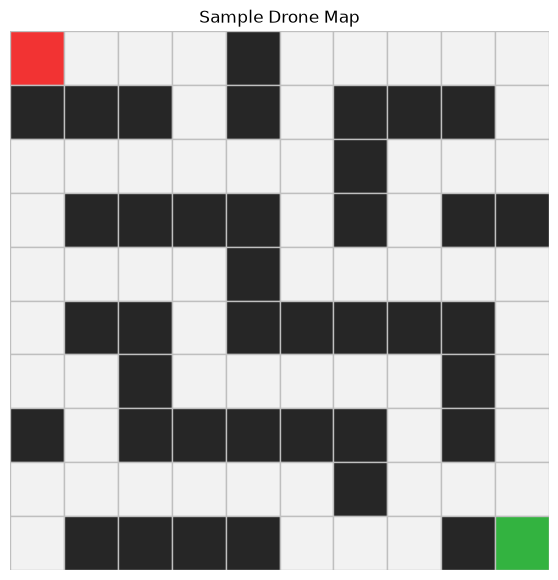

In [267]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [268]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].

        return self.terrain_costs[next_state[0]][next_state[1]]

In [269]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [270]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    # 2. Return abs(r1 - r2) + abs(c1 - c2).

    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    # Hint: math.sqrt(...) or math.dist(state, goal).

    r1, c1 = state
    r2, c2 = goal
    return math.sqrt((r1 - r2) ** 2 + (c1 - c2) ** 2)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [271]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [272]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [273]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        initial_node = Node(state=problem.initial_state())

        frontier = PriorityQueue()
        frontier.push(self.evaluation(initial_node, problem), initial_node)

        REACHED = {problem.initial_state(): initial_node}

        nodes_expanded = 0
        max_frontier_size = 1

        while len(frontier) > 0:
            node = frontier.pop()

            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(REACHED),
                )

            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state
                if s not in REACHED or child.path_cost < REACHED[s].path_cost:
                    REACHED[s] = child
                    frontier.push(self.evaluation(child, problem), child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(REACHED),
        )


In [274]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).

        f_n = self.h(node, problem)
        return f_n

In [275]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        g = node.path_cost
        h = self.h(node, problem)

        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.

        f_n = g + h
        return f_n


In [276]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [277]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n)

        g = node.path_cost
        h = self.h(node, problem)
        w = self.weight
        f_n = g + w * h
        return f_n

In [278]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, (
        f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    )
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0], [1, 1, 0], [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [279]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


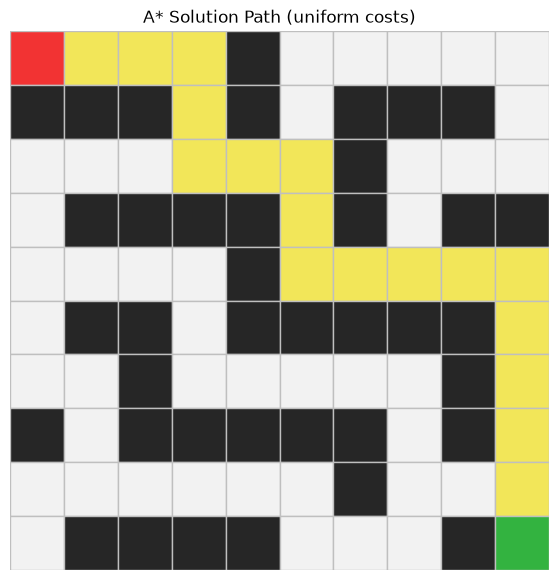

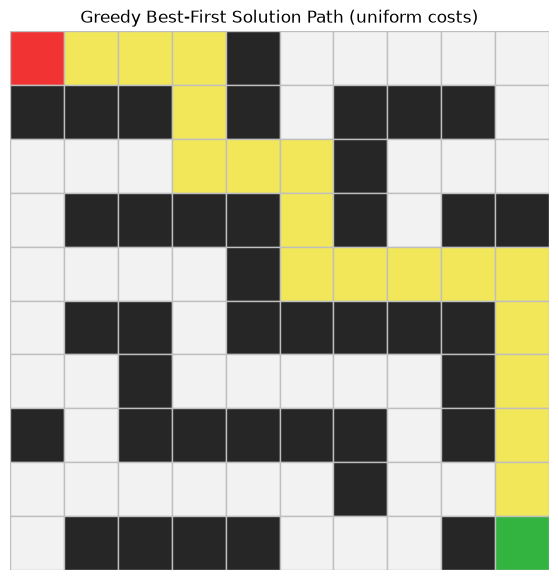

In [280]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

In [281]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


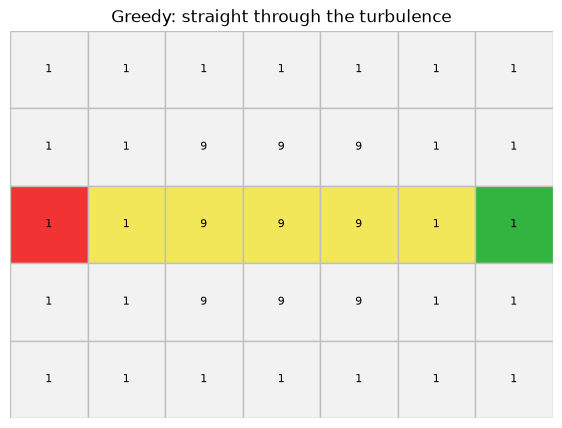

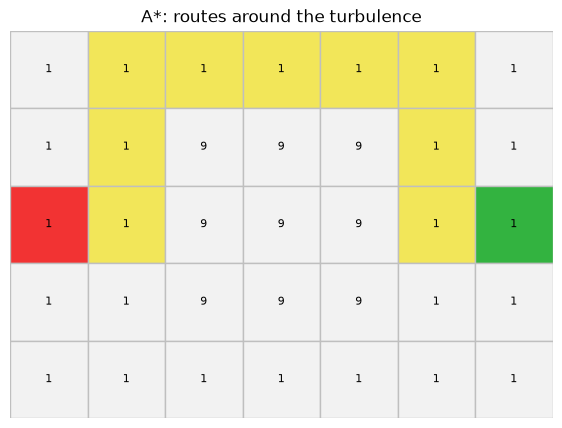

In [ ]:
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)


In [283]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h

    def h(state, goal):
        return factor * manhattan_distance(state, goal)

    return h


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


1.On which map(s) did the inflated heuristic return a suboptimal path? By how much?
optimal - A* admissible (mild turbulence) cost = 10
subotimal - A* inflated x3 (mild turbulence) cost = 12
difference in cost = 2

2.How many fewer nodes did it expand?
23 fewer nodes.

3.In one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?
The drone is searching for environmental degradation so if an accident occurs and rescue is needed the engineer might go for the inadmissible heuristic.



In [ ]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 0
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],  # 1  ← U top-left wall
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 2
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 3
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 4
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 5
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 6
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 7
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 8
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 9
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 10
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],  # 11
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],  # 12 ← U bottom wall
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 13
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 14
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_1 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
    [1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1],  # 0  ← cheap exterior
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1],  # 1  ← wall row
    [2, 1, 8, 9, 8, 7, 8, 9, 8, 7, 8, 9, 8, 1, 2, 1],  # 2  ← brutal pocket
    [1, 1, 7, 8, 9, 8, 7, 8, 9, 8, 7, 8, 9, 1, 1, 1],  # 3  ← brutal pocket
    [2, 1, 6, 7, 8, 9, 8, 7, 6, 7, 8, 9, 7, 1, 2, 1],  # 4  ← brutal pocket
    [1, 1, 5, 6, 7, 8, 9, 8, 5, 6, 7, 8, 6, 1, 1, 1],  # 5  ← expensive pocket
    [1, 1, 4, 5, 6, 7, 8, 7, 4, 5, 6, 7, 5, 1, 3, 1],  # 6  ← expensive pocket
    [2, 1, 5, 6, 7, 8, 7, 6, 5, 6, 7, 6, 5, 1, 2, 1],  # 7  ← expensive pocket
    [1, 1, 6, 7, 8, 9, 8, 7, 6, 7, 8, 7, 6, 1, 1, 1],  # 8  ← expensive pocket
    [1, 1, 7, 8, 9, 8, 7, 8, 7, 8, 9, 8, 7, 1, 2, 1],  # 9  ← brutal pocket
    [2, 1, 8, 9, 8, 7, 8, 9, 8, 9, 8, 7, 8, 1, 1, 1],  # 10 ← brutal pocket
    [1, 1, 9, 8, 7, 8, 9, 8, 7, 8, 9, 8, 9, 1, 3, 1],  # 11 ← brutal pocket
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # 12 ← wall row
    [1, 2, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2, 1, 2, 1, 1],  # 13 ← mild exterior
    [2, 1, 2, 3, 2, 1, 2, 3, 4, 3, 2, 1, 2, 3, 2, 1],  # 14 ← mild exterior
    [1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1],
]

custom_start_1 = (0, 0)
custom_goal_1 = (15, 15)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,30,34,87,9,94
1,A*,success,30,34,43,17,60
2,Weighted A* (W=2),success,30,38,31,17,48
3,Greedy,success,30,38,30,17,47


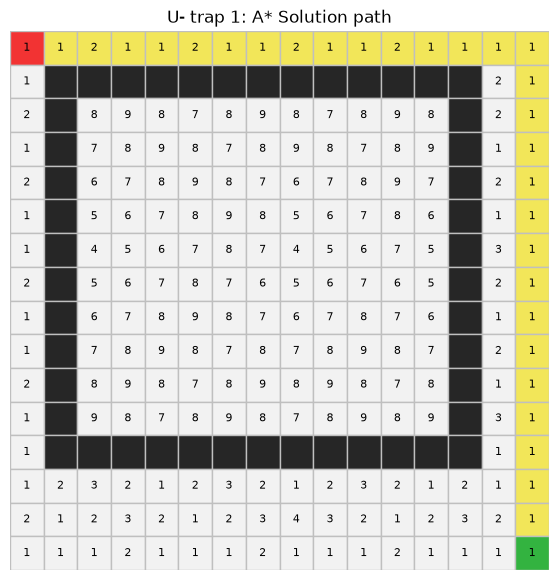

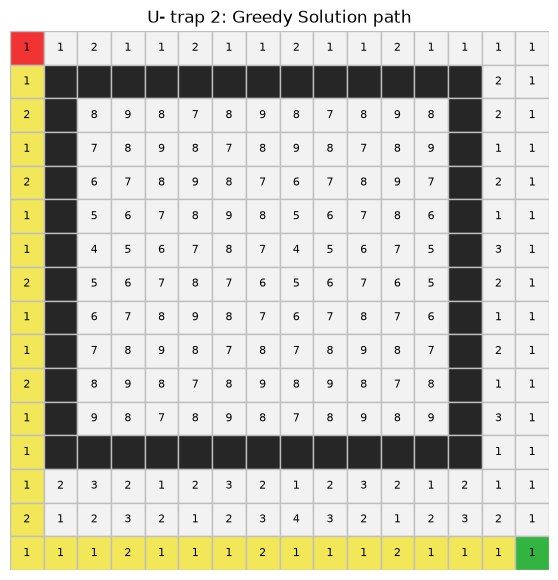

In [285]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="U- trap 1: A* Solution path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[3].path,
    terrain_costs=custom_costs_1,
    title="U- trap 2: Greedy Solution path",
)


In [ ]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    #   0  1  2  3  4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 0
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 1
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 2
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 3
    [
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        0,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        0,
    ],  # 4  ← wall, gap at col 9
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 5
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 6
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 7
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 8
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 9
    [
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        0,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        0,
    ],  # 10 ← wall, gap at col 11
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 11
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 12
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 13
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 14
    [
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        0,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        1,
        0,
    ],  # 15 ← wall, gap at col 7
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 16
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 17
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 18
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # 19
]

custom_costs_2 = [
    #   0  1  2  3  4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19
    [1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1],  # 0  ← mostly cheap
    [1, 2, 2, 3, 1, 1, 2, 1, 2, 1, 1, 3, 1, 2, 1, 1, 1, 2, 1, 1],  # 1
    [3, 4, 5, 6, 7, 6, 5, 4, 3, 4, 5, 6, 7, 6, 5, 4, 3, 4, 5, 3],  # 2  ← rising band
    [6, 7, 8, 9, 8, 7, 8, 9, 8, 7, 8, 9, 8, 7, 8, 9, 8, 7, 6, 5],  # 3  ← brutal band
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # 4  ← wall row
    [4, 5, 6, 7, 6, 5, 4, 5, 6, 7, 6, 5, 4, 5, 6, 7, 6, 5, 4, 3],  # 5  ← wavy expensive
    [
        7,
        8,
        9,
        8,
        7,
        6,
        5,
        4,
        5,
        6,
        7,
        8,
        9,
        8,
        7,
        6,
        5,
        4,
        3,
        2,
    ],  # 6  ← expensive, eases right
    [8, 9, 9, 8, 7, 6, 5, 4, 3, 2, 2, 3, 4, 5, 6, 7, 8, 9, 8, 7],  # 7  ← V-shaped cost
    [6, 7, 8, 7, 6, 5, 4, 3, 2, 1, 1, 2, 3, 4, 5, 6, 7, 8, 7, 6],  # 8  ← V-shaped cost
    [1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1],  # 9  ← cheap corridor
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # 10 ← wall row
    [3, 4, 5, 6, 5, 4, 3, 4, 5, 6, 5, 4, 3, 4, 5, 6, 5, 4, 3, 2],  # 11 ← moderate band
    [6, 7, 8, 9, 8, 7, 6, 5, 4, 3, 3, 4, 5, 6, 7, 8, 9, 8, 7, 6],  # 12 ← expensive
    [8, 9, 9, 8, 7, 6, 5, 4, 3, 2, 2, 3, 4, 5, 6, 7, 8, 9, 9, 8],  # 13 ← very expensive
    [5, 6, 7, 8, 7, 6, 5, 4, 3, 2, 2, 3, 4, 5, 6, 7, 8, 7, 6, 5],  # 14 ← easing off
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # 15 ← wall row
    [4, 5, 6, 7, 8, 9, 8, 7, 6, 5, 4, 3, 2, 3, 4, 5, 6, 7, 8, 9],  # 16 ← rising right
    [
        7,
        8,
        9,
        9,
        8,
        7,
        6,
        5,
        4,
        3,
        2,
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
    ],  # 17 ← expensive, cheap middle
    [1, 2, 3, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1],  # 18 ← cheap corridor
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],  # 19 ← cheap
]

custom_start_2 = (0, 0)
custom_goal_2 = (19, 19)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,38,96,317,28,335
1,A*,success,38,96,241,28,258
2,Weighted A* (W=2),success,38,96,272,41,214
3,Greedy,success,38,185,38,41,79


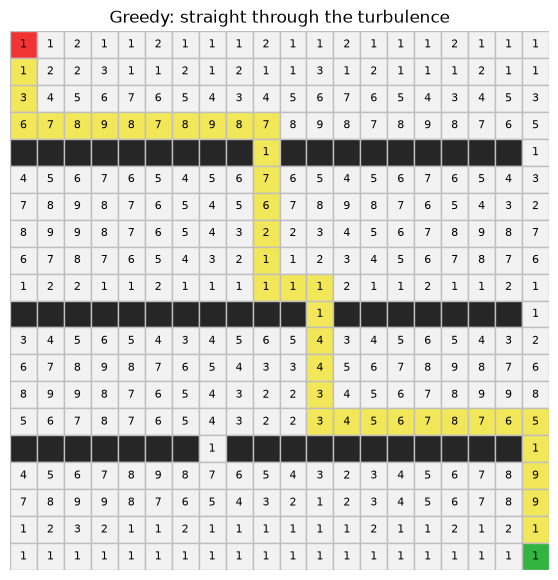

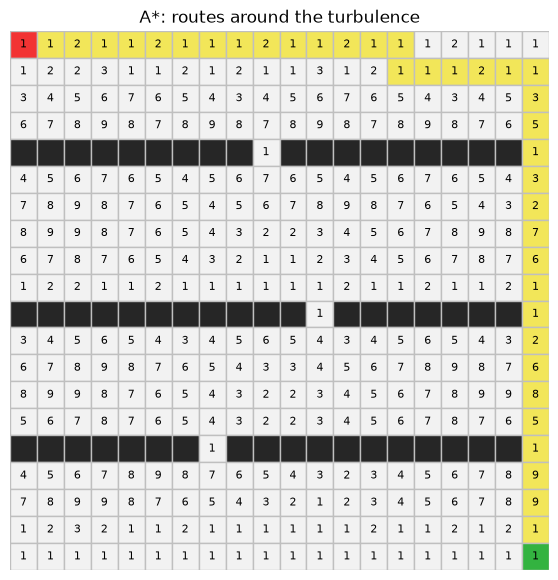

In [287]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Greedy: straight through the turbulence",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    terrain_costs=custom_costs_2,
    title="A*: routes around the turbulence",
)


16. Reflection Questions
Answer the questions below in markdown cells.
16.1 Heuristic Functions
1.	In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?
This is the estimate of the remaining cost after some costs are covered along the cheapest path to the goal, as an agent moves from one node to another.  In this lab, the drone searches for the cheapest path to the goal state from the initial state using the GPS, while avoiding obstacles.
2.	Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?
The obstacles – it estimates the number of moves needed if there are no obstacles.
3.	Both Manhattan and Euclidean distances are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?
The Manhattan distance is more admissible because the drone moves up, down, right, and left to reach the goal, but for the Euclidean, if it uses a straight line, it could be diagonal, and the drone cannot move in that direction.
4.	Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?
This is because, for the uninformed search, we didn’t know the different costs in the state space; hence, we set all costs to 1. But in the informed search, more information is provided on the different costs/obstacles, and all are 1 or above, so using 0.5 would result in an error because it does not exist as a cost. 
16.2 Greedy Best-First Search
1.	Which quantity does Greedy ignore, and how did the turbulence map punish it for that?
It ignores the covered cost and focuses only on the heuristic cost. Greedy bears the highest cost of 30 amongst the other search algorithms.
2.	Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?
Greedy ignores all long paths and takes the shortest path using a priority queue. It is the turbulence map that determines the path, but not optimally.

3.	Describe a drone mission where Greedy's behavior would actually be acceptable.
In a time cost problem where time is of more concern than the solution cost incurred.


16.4 Admissibility and Consistency
1.	State the definitions of admissible and consistent. Which implies which?
The term admissible means that the heuristic or cost to be covered is not overestimated compared to the true cost. The consistency stems from the fact that the heuristic would be shorter than the total optimal path cost from the initial node to the goal. Every consistent heuristic is admissible.
2.	What did your inadmissible heuristic experiment show about the lecture's optimality claim?
That, depending on the situation or problem, the inadmissible heuristic may be preferred.
3.	Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.

